# Energy Real-Data Results / Energy 真实数据结果

This notebook consolidates the formal energy real-data suite: CMDL, plain-LSTM baseline, and the three core ablation variants.
本 notebook 汇总 energy 真实数据正式实验：CMDL、plain-LSTM baseline，以及三个核心 ablation 变体。

## Sections / 结构

- Setup: repo paths, imports, and the single configuration cell.
- Optional direct-run: programmatic training hooks for CMDL, baseline, and ablation.
- Unified comparison: build normalized run-level tables for forecasting and lag/proxy diagnostics.
- Seed summaries and plots: aggregate the formal CMDL versus plain-LSTM runs and export figures.
- Prediction snapshots: compare canonical CMDL and baseline runs on representative entities.
- Verdict log: summarize what the energy domain currently supports.

## Defaults / 默认行为

- The active plan is `formal_target`.
- Direct-run switches are opt-in and default to `False`.
- The notebook reads from `data/energy/raw/energy_wgi_merged.csv`.
- The standardized target name `co2_per_unit_energy` is currently sourced from OWID `carbon_intensity_elec`.
- Outputs are organized under `outputs/notebook_energy/<plan>/...`.

In [ ]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

current = Path.cwd().resolve()
repo_root = next(
    (
        path
        for path in [current, *current.parents]
        if (path / "config").exists() and (path / "data").exists() and (path / "experiments").exists()
    ),
    None,
)

if repo_root is None:
    raise RuntimeError(f"Could not find repo root from {current}")

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print(f"repo_root = {repo_root}")

repo_root = C:\DevSpace\PyDevspace\CMDL


In [2]:
import importlib

from evaluation import energy_comparison as energy_comparison_module

energy_comparison_module = importlib.reload(energy_comparison_module)
build_energy_comparison = energy_comparison_module.build_energy_comparison
build_task_table = energy_comparison_module.build_task_table
build_interpretability_table = energy_comparison_module.build_interpretability_table

PRESET_CONFIGS = {
    "quick_check": {"epochs": 3, "patience": 1, "log_every": 1},
    "notebook_medium": {"epochs": 30, "patience": 8, "log_every": 5},
    "formal_target": {"epochs": 120, "patience": 20, "log_every": 20},
}

ACTIVE_PLAN = "formal_target"
SEEDS = [0, 1, 2]
ABLATION_SEEDS = [0]
CANONICAL_SEED = SEEDS[0]
RUN_CMDL = False
RUN_BASELINE = False
RUN_ABLATIONS = False
DISABLE_MLFLOW = True
TREATMENT_COLUMN = "renewables_share_energy"
TARGET_COLUMN = "co2_per_unit_energy"
TARGET_SOURCE_NOTE = "OWID carbon_intensity_elec standardized as co2_per_unit_energy"

DATA_PATH = repo_root / "data" / "energy" / "raw" / "energy_wgi_merged.csv"
OUTPUT_ROOT = repo_root / "outputs" / "notebook_energy" / ACTIVE_PLAN
CMDL_OUTPUT_DIR = OUTPUT_ROOT / "cmdl"
BASELINE_OUTPUT_DIR = OUTPUT_ROOT / "plain_lstm"
ABLATION_OUTPUT_DIR = OUTPUT_ROOT / "ablation"
COMPARISON_DIR = OUTPUT_ROOT / "comparison"
PLOTS_DIR = OUTPUT_ROOT / "comparison_plots"

for path in [OUTPUT_ROOT, CMDL_OUTPUT_DIR, BASELINE_OUTPUT_DIR, ABLATION_OUTPUT_DIR, COMPARISON_DIR, PLOTS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

COMMON_ARGS = {
    "csv_path": str(DATA_PATH),
    "year_start": 1996,
    "year_end": 2023,
    "train_end_year": 2011,
    "val_end_year": 2017,
    "treatment_column": TREATMENT_COLUMN,
    "target_column": TARGET_COLUMN,
    "feature_bundle": "minimal",
    "max_missing_share": 0.15,
    "lr": 1e-3,
    "lambda_r": 0.1,
    "temperature": 1.0,
    "lag_bias_strength": 1.0,
    "grad_clip": 1.0,
    "device": "auto",
    "disable_mlflow": DISABLE_MLFLOW,
}

plan_table = pd.DataFrame.from_dict(PRESET_CONFIGS, orient="index")
notebook_switches = pd.DataFrame(
    {
        "value": [
            ACTIVE_PLAN,
            DATA_PATH,
            TARGET_SOURCE_NOTE,
            CMDL_OUTPUT_DIR,
            BASELINE_OUTPUT_DIR,
            ABLATION_OUTPUT_DIR,
            COMPARISON_DIR,
            PLOTS_DIR,
            ", ".join(str(seed) for seed in SEEDS),
            ", ".join(str(seed) for seed in ABLATION_SEEDS),
            CANONICAL_SEED,
            RUN_CMDL,
            RUN_BASELINE,
            RUN_ABLATIONS,
            DISABLE_MLFLOW,
        ]
    },
    index=[
        "ACTIVE_PLAN",
        "DATA_PATH",
        "TARGET_SOURCE_NOTE",
        "CMDL_OUTPUT_DIR",
        "BASELINE_OUTPUT_DIR",
        "ABLATION_OUTPUT_DIR",
        "COMPARISON_DIR",
        "PLOTS_DIR",
        "SEEDS",
        "ABLATION_SEEDS",
        "CANONICAL_SEED",
        "RUN_CMDL",
        "RUN_BASELINE",
        "RUN_ABLATIONS",
        "DISABLE_MLFLOW",
    ],
)

display(plan_table)
display(pd.Series({**COMMON_ARGS, **PRESET_CONFIGS[ACTIVE_PLAN]}, name="value").to_frame())
display(notebook_switches)
print(f"ACTIVE_PLAN = {ACTIVE_PLAN}")
print(f"OUTPUT_ROOT = {OUTPUT_ROOT}")

,epochs,patience,log_every
quick_check,3,1,1
notebook_medium,30,8,5
formal_target,120,20,20


,value
csv_path,C:\DevSpace\PyDevspace\CMDL\data\energy\raw\en...
year_start,1996
year_end,2023
train_end_year,2011
val_end_year,2017
treatment_column,renewables_share_energy
target_column,co2_per_unit_energy
feature_bundle,minimal
max_missing_share,0.15
lr,0.001


,value
ACTIVE_PLAN,formal_target
DATA_PATH,C:\DevSpace\PyDevspace\CMDL\data\energy\raw\en...
TARGET_SOURCE_NOTE,OWID carbon_intensity_elec standardized as co2...
CMDL_OUTPUT_DIR,C:\DevSpace\PyDevspace\CMDL\outputs\notebook_e...
BASELINE_OUTPUT_DIR,C:\DevSpace\PyDevspace\CMDL\outputs\notebook_e...
ABLATION_OUTPUT_DIR,C:\DevSpace\PyDevspace\CMDL\outputs\notebook_e...
COMPARISON_DIR,C:\DevSpace\PyDevspace\CMDL\outputs\notebook_e...
PLOTS_DIR,C:\DevSpace\PyDevspace\CMDL\outputs\notebook_e...
SEEDS,"0, 1, 2"
ABLATION_SEEDS,0


ACTIVE_PLAN = formal_target
OUTPUT_ROOT = C:\DevSpace\PyDevspace\CMDL\outputs\notebook_energy\formal_target


In [9]:
RUN_CMDL = True
RUN_BASELINE = True
RUN_ABLATIONS = True
print({
    "RUN_CMDL": RUN_CMDL,
    "RUN_BASELINE": RUN_BASELINE,
    "RUN_ABLATIONS": RUN_ABLATIONS,
    "ACTIVE_PLAN": ACTIVE_PLAN,
    "SEEDS": SEEDS,
    "ABLATION_SEEDS": ABLATION_SEEDS,
})

{'RUN_CMDL': True, 'RUN_BASELINE': True, 'RUN_ABLATIONS': True, 'ACTIVE_PLAN': 'formal_target', 'SEEDS': [0, 1, 2], 'ABLATION_SEEDS': [0]}


In [10]:
from argparse import Namespace

if RUN_CMDL or RUN_BASELINE or RUN_ABLATIONS:
    from experiments import run_energy as run_energy_module
    from experiments import run_energy_ablation as run_energy_ablation_module
    from experiments import run_energy_lstm_baseline as run_energy_lstm_baseline_module

    run_energy_module = importlib.reload(run_energy_module)
    run_energy_ablation_module = importlib.reload(run_energy_ablation_module)
    run_energy_lstm_baseline_module = importlib.reload(run_energy_lstm_baseline_module)

    run_cmdl_experiment = run_energy_module.run_experiment
    run_baseline_experiment = run_energy_lstm_baseline_module.run_experiment
    run_ablation_suite = run_energy_ablation_module.run_suite
else:
    run_cmdl_experiment = None
    run_baseline_experiment = None
    run_ablation_suite = None

cmdl_summaries: list[dict[str, object]] = []
baseline_summaries: list[dict[str, object]] = []
ablation_summary_frame = pd.DataFrame()
ablation_aggregated_frame = pd.DataFrame()

if RUN_CMDL:
    for seed in SEEDS:
        cmdl_args = Namespace(
            **COMMON_ARGS,
            **PRESET_CONFIGS[ACTIVE_PLAN],
            seed=seed,
            output_dir=str(CMDL_OUTPUT_DIR),
            experiment_name=f"E3_energy_cmdl_seed{seed}",
            smoke=ACTIVE_PLAN == "quick_check",
        )
        cmdl_summary = run_cmdl_experiment(cmdl_args)
        cmdl_summaries.append(cmdl_summary)
        print(
            f"CMDL seed={seed} test_r2={cmdl_summary['metrics']['test']['r2']:.4f} "
            f"test_mae={cmdl_summary['metrics']['test']['mae']:.4f}"
        )
else:
    print("RUN_CMDL = False; skipping direct CMDL training.")

if RUN_BASELINE:
    for seed in SEEDS:
        baseline_args = Namespace(
            **COMMON_ARGS,
            **PRESET_CONFIGS[ACTIVE_PLAN],
            seed=seed,
            output_dir=str(BASELINE_OUTPUT_DIR),
            experiment_name=f"E3_energy_lstm_seed{seed}",
            smoke=ACTIVE_PLAN == "quick_check",
        )
        baseline_summary = run_baseline_experiment(baseline_args)
        baseline_summaries.append(baseline_summary)
        print(
            f"Baseline seed={seed} test_r2={baseline_summary['metrics']['test']['r2']:.4f} "
            f"test_mae={baseline_summary['metrics']['test']['mae']:.4f}"
        )
else:
    print("RUN_BASELINE = False; skipping direct baseline training.")

if RUN_ABLATIONS:
    ablation_args = Namespace(
        **COMMON_ARGS,
        **PRESET_CONFIGS[ACTIVE_PLAN],
        variant="all",
        seeds=ABLATION_SEEDS,
        output_dir=str(ABLATION_OUTPUT_DIR),
        experiment_prefix="E3_energy_ablation",
        smoke=ACTIVE_PLAN == "quick_check",
    )
    ablation_summary_frame, ablation_aggregated_frame = run_ablation_suite(ablation_args)
    display(ablation_summary_frame)
    if not ablation_aggregated_frame.empty:
        display(ablation_aggregated_frame)
else:
    print("RUN_ABLATIONS = False; skipping direct ablation training.")

c:\Users\42155\anaconda3\envs\PTenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[E3_energy_cmdl_seed0] epoch=001 train_total=1.8079 val_task=17.5378 val_r2=-0.0686 val_proxy_r2=-0.1003
[E3_energy_cmdl_seed0] epoch=020 train_total=0.6906 val_task=14.2452 val_r2=0.1666 val_proxy_r2=-0.1113
[E3_energy_cmdl_seed0] epoch=040 train_total=0.4363 val_task=15.9695 val_r2=0.0273 val_proxy_r2=-0.0158
[E3_energy_cmdl_seed0] early stopping at epoch 40
CMDL seed=0 test_r2=-0.0265 test_mae=16.6946
[E3_energy_cmdl_seed1] epoch=001 train_total=1.7225 val_task=17.1520 val_r2=-0.0433 val_proxy_r2=-0.3798
[E3_energy_cmdl_seed1] epoch=020 train_total=0.6878 val_task=14.0306 val_r2=0.1867 val_proxy_r2=-0.3775
[E3_energy_cmdl_seed1] epoch=040 train_total=0.4411 val_task=17.1794 val_r2=-0.0281 val_proxy_r2=-0.3409
[E3_energy_cmdl_seed1] early stopping at epoch 41
CMDL seed=1 test_r2=-0.0242 test_mae=16.7748
[E3_energy_cmdl_seed2] epoch=001 train_total=1.7390 val_task=17.1319 val_r2=-0.0463 val_proxy_r2=-0.1234
[E3_energy_cmdl_seed2] epoch=020 train_total=0.6390 val_task=14.8734 val_r2=0.

,experiment,model,variant,treatment_column,target_column,source_path,seed,effective_lambda_r,matched_init_to_full_cmdl,causal_ablation_validity,...,test_mae,test_r2,test_proxy_recon_r2,test_proxy_metric_valid,test_kstar_proxy_spearman_rho,test_kstar_proxy_spearman_p,test_kstar_mean,test_kstar_std,test_kstar_proxy_metric_valid,test_omega_entropy_mean
0,E3_energy_ablation_no_ac_encoder_seed0,cmdl_ablation,no_ac_encoder,renewables_share_energy,co2_per_unit_energy,C:\DevSpace\PyDevspace\CMDL\data\energy\raw\en...,0,0.0,False,architecture_changed,...,16.552314,-0.018752,NaN,0.0,NaN,NaN,3.492620,0.000000,0.0,1.717546
1,E3_energy_ablation_uniform_lag_seed0,cmdl_ablation,uniform_lag,renewables_share_energy,co2_per_unit_energy,C:\DevSpace\PyDevspace\CMDL\data\energy\raw\en...,0,0.1,False,architecture_changed,...,16.739664,-0.024461,0.866660,1.0,NaN,NaN,5.500000,0.000000,0.0,2.302585
2,E3_energy_ablation_no_recon_regularization_seed0,cmdl_ablation,no_recon_regularization,renewables_share_energy,co2_per_unit_energy,C:\DevSpace\PyDevspace\CMDL\data\energy\raw\en...,0,0.0,True,matched_init_effective_lambda_only,...,16.694616,-0.026533,0.464989,1.0,-0.663172,3.704763e-11,4.731955,0.061845,1.0,1.886401


,variant,treatment_column,target_column,effective_lambda_r_mean,effective_lambda_r_std,matched_init_to_full_cmdl_mean,matched_init_to_full_cmdl_std,best_epoch_mean,best_epoch_std,best_val_task_loss_mean,...,test_kstar_proxy_spearman_p_mean,test_kstar_proxy_spearman_p_std,test_kstar_mean_mean,test_kstar_mean_std,test_kstar_std_mean,test_kstar_std_std,test_kstar_proxy_metric_valid_mean,test_kstar_proxy_metric_valid_std,test_omega_entropy_mean_mean,test_omega_entropy_mean_std
0,no_ac_encoder,renewables_share_energy,co2_per_unit_energy,0.0,NaN,0.0,NaN,15.0,NaN,13.791987,...,NaN,NaN,3.492620,NaN,0.000000,NaN,0.0,NaN,1.717546,NaN
1,no_recon_regularization,renewables_share_energy,co2_per_unit_energy,0.0,NaN,1.0,NaN,20.0,NaN,14.245145,...,3.704763e-11,NaN,4.731955,NaN,0.061845,NaN,1.0,NaN,1.886401,NaN
2,uniform_lag,renewables_share_energy,co2_per_unit_energy,0.1,NaN,0.0,NaN,20.0,NaN,14.200980,...,NaN,NaN,5.500000,NaN,0.000000,NaN,0.0,NaN,2.302585,NaN


In [11]:
comparison = build_energy_comparison(
    cmdl_root=CMDL_OUTPUT_DIR,
    baseline_root=BASELINE_OUTPUT_DIR,
    ablation_root=ABLATION_OUTPUT_DIR,
)
task_table = build_task_table(comparison)
interpretability_table = build_interpretability_table(comparison)

comparison.to_csv(COMPARISON_DIR / "energy_comparison.csv", index=False)
task_table.to_csv(COMPARISON_DIR / "energy_forecast_comparison.csv", index=False)
interpretability_table.to_csv(COMPARISON_DIR / "energy_interpretability_comparison.csv", index=False)

display(task_table)
display(interpretability_table)
print(comparison.groupby("family").size().to_string())

,display_name,family,variant,seed,experiment,target_column,feature_bundle,best_epoch,best_val_task_loss,test_r2,test_mae,test_mse
0,No AC Encoder,ablation,no_ac_encoder,0,E3_energy_ablation_no_ac_encoder_seed0,co2_per_unit_energy,minimal,15,13.791987,-0.018752,16.552314,24173.059529
1,CMDL,cmdl,None,1,E3_energy_cmdl_seed1,co2_per_unit_energy,minimal,21,13.996673,-0.024178,16.774849,24180.133730
2,Uniform Lag,ablation,uniform_lag,0,E3_energy_ablation_uniform_lag_seed0,co2_per_unit_energy,minimal,20,14.200980,-0.024461,16.739664,24180.637765
3,CMDL,cmdl,None,0,E3_energy_cmdl_seed0,co2_per_unit_energy,minimal,20,14.245157,-0.026533,16.694622,24185.818405
4,No Recon Regularization,ablation,no_recon_regularization,0,E3_energy_ablation_no_recon_regularization_seed0,co2_per_unit_energy,minimal,20,14.245145,-0.026533,16.694616,24185.818884
5,Plain LSTM,plain_lstm,None,1,E3_energy_lstm_seed1,co2_per_unit_energy,minimal,27,14.483810,-0.031102,17.040019,24183.932358
6,Plain LSTM,plain_lstm,None,0,E3_energy_lstm_seed0,co2_per_unit_energy,minimal,20,14.458306,-0.032463,16.883667,24186.494682
7,CMDL,cmdl,None,2,E3_energy_cmdl_seed2,co2_per_unit_energy,minimal,23,14.601487,-0.034003,17.018583,24183.937787
8,Plain LSTM,plain_lstm,None,2,E3_energy_lstm_seed2,co2_per_unit_energy,minimal,25,14.848111,-0.035597,17.023568,24212.288915


,display_name,family,variant,seed,experiment,target_column,feature_bundle,lag_method,proxy_refit_status,proxy_metric_interpretable,test_effective_kstar_proxy_spearman_rho,test_effective_kstar_proxy_metric_valid,test_effective_kstar_mean,test_effective_kstar_std,test_effective_lag_entropy_mean,test_proxy_signal_r2,test_proxy_signal_metric_valid
0,CMDL,cmdl,None,1,E3_energy_cmdl_seed1,co2_per_unit_energy,minimal,learned_omega,applied_ols,True,0.877439,True,3.794667,0.112163,1.886324,0.808135,True
1,Plain LSTM,plain_lstm,None,2,E3_energy_lstm_seed2,co2_per_unit_energy,minimal,lag_occlusion,None,None,0.039367,True,5.457396,1.154389,2.151947,NaN,None
2,Plain LSTM,plain_lstm,None,0,E3_energy_lstm_seed0,co2_per_unit_energy,minimal,lag_occlusion,None,None,-0.017147,True,5.458454,1.304674,2.103978,NaN,None
3,Plain LSTM,plain_lstm,None,1,E3_energy_lstm_seed1,co2_per_unit_energy,minimal,lag_occlusion,None,None,-0.201703,True,5.629081,1.611144,1.985952,NaN,None
4,No Recon Regularization,ablation,no_recon_regularization,0,E3_energy_ablation_no_recon_regularization_seed0,co2_per_unit_energy,minimal,learned_omega,applied_ols,True,-0.663172,True,4.731955,0.061845,1.886401,0.464989,True
5,CMDL,cmdl,None,0,E3_energy_cmdl_seed0,co2_per_unit_energy,minimal,learned_omega,applied_ols,True,-0.663172,True,4.731988,0.061838,1.886402,0.464952,True
6,CMDL,cmdl,None,2,E3_energy_cmdl_seed2,co2_per_unit_energy,minimal,learned_omega,applied_ols,True,-0.919220,True,4.367868,0.143586,1.739563,0.829005,True
7,Uniform Lag,ablation,uniform_lag,0,E3_energy_ablation_uniform_lag_seed0,co2_per_unit_energy,minimal,learned_omega,applied_ols,True,NaN,False,5.500000,0.000000,2.302585,0.866660,True
8,No AC Encoder,ablation,no_ac_encoder,0,E3_energy_ablation_no_ac_encoder_seed0,co2_per_unit_energy,minimal,learned_omega,skipped_rank_deficient,False,NaN,False,3.492620,0.000000,1.717546,NaN,False


family
ablation      3
cmdl          3
plain_lstm    3


In [12]:
seed_frame = comparison.loc[comparison["family"].isin(["cmdl", "plain_lstm"])].copy()
seed_summary = (
    seed_frame.groupby(["family", "display_name"], as_index=False)
    .agg(
        test_r2_mean=("test_r2", "mean"),
        test_r2_std=("test_r2", "std"),
        test_mae_mean=("test_mae", "mean"),
        test_mae_std=("test_mae", "std"),
        test_proxy_signal_r2_mean=("test_proxy_signal_r2", "mean"),
        test_proxy_signal_r2_std=("test_proxy_signal_r2", "std"),
        test_effective_kstar_proxy_spearman_rho_mean=("test_effective_kstar_proxy_spearman_rho", "mean"),
        test_effective_kstar_proxy_spearman_rho_std=("test_effective_kstar_proxy_spearman_rho", "std"),
        test_effective_kstar_std_mean=("test_effective_kstar_std", "mean"),
        test_effective_kstar_std_std=("test_effective_kstar_std", "std"),
    )
)
seed_summary.to_csv(COMPARISON_DIR / "energy_seed_summary.csv", index=False)
display(seed_summary)

canonical = {}
for family in ["cmdl", "plain_lstm"]:
    family_frame = comparison.loc[comparison["family"] == family].sort_values(
        ["test_r2", "test_effective_kstar_std"],
        ascending=[False, False],
        na_position="last",
    )
    if not family_frame.empty:
        row = family_frame.iloc[0]
        canonical[family] = {
            "experiment": row["experiment"],
            "run_dir": row["run_dir"],
            "test_r2": None if pd.isna(row["test_r2"]) else float(row["test_r2"]),
            "test_mae": None if pd.isna(row["test_mae"]) else float(row["test_mae"]),
        }

with (COMPARISON_DIR / "canonical_runs.json").open("w", encoding="utf-8") as handle:
    json.dump(canonical, handle, indent=2, ensure_ascii=True)

display(pd.DataFrame(canonical).T)

,family,display_name,test_r2_mean,test_r2_std,test_mae_mean,test_mae_std,test_proxy_signal_r2_mean,test_proxy_signal_r2_std,test_effective_kstar_proxy_spearman_rho_mean,test_effective_kstar_proxy_spearman_rho_std,test_effective_kstar_std_mean,test_effective_kstar_std_std
0,cmdl,CMDL,-0.028238,0.005130,16.829351,0.168718,0.700697,0.204428,-0.234984,0.971856,0.105862,0.041237
1,plain_lstm,Plain LSTM,-0.033054,0.002305,16.982418,0.085916,NaN,NaN,-0.059828,0.126075,1.356736,0.232785


,experiment,run_dir,test_r2,test_mae
cmdl,E3_energy_cmdl_seed1,C:\DevSpace\PyDevspace\CMDL\outputs\notebook_e...,-0.024178,16.774849
plain_lstm,E3_energy_lstm_seed1,C:\DevSpace\PyDevspace\CMDL\outputs\notebook_e...,-0.031102,17.040019


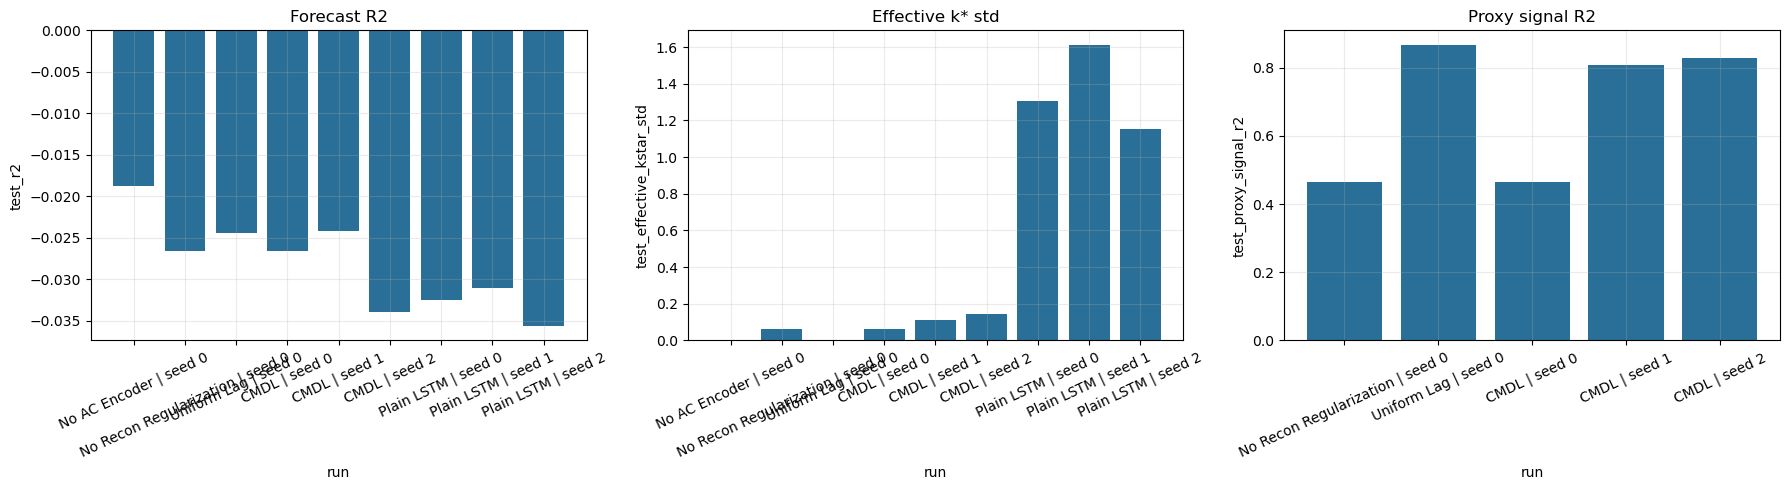

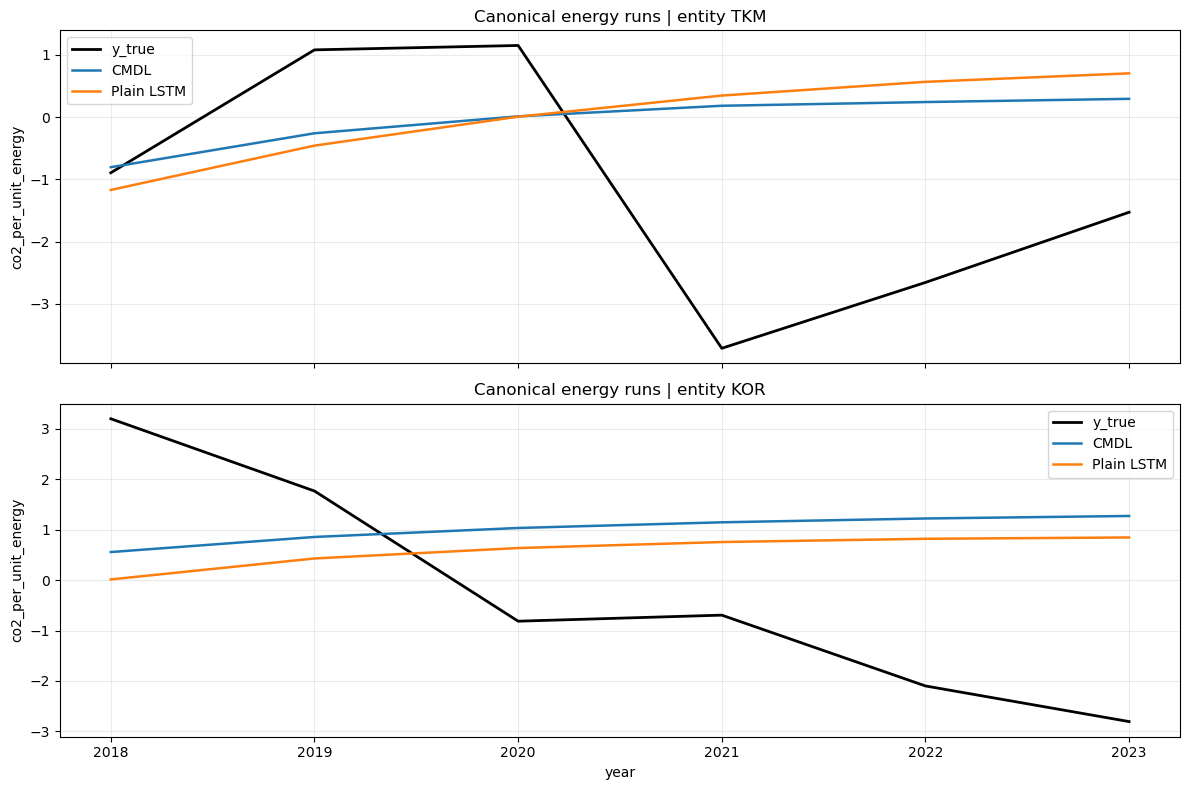

,display_name,seed,test_r2,test_mae,test_effective_kstar_proxy_spearman_rho,test_effective_kstar_std,test_proxy_signal_r2
3,CMDL,0,-0.026533,16.694622,-0.663172,0.061838,0.464952
4,CMDL,1,-0.024178,16.774849,0.877439,0.112163,0.808135
5,CMDL,2,-0.034003,17.018583,-0.919220,0.143586,0.829005
6,Plain LSTM,0,-0.032463,16.883667,-0.017147,1.304674,NaN
7,Plain LSTM,1,-0.031102,17.040019,-0.201703,1.611144,NaN
8,Plain LSTM,2,-0.035597,17.023568,0.039367,1.154389,NaN


Saved plots to C:\DevSpace\PyDevspace\CMDL\outputs\notebook_energy\formal_target\comparison_plots\energy_formal_metrics.png and C:\DevSpace\PyDevspace\CMDL\outputs\notebook_energy\formal_target\comparison_plots\energy_prediction_snapshots.png


In [13]:
if comparison.empty:
    print("No formal energy results found; skipping plots.")
else:
    plot_frame = comparison.copy()
    plot_frame["run_label"] = plot_frame["display_name"] + " | seed " + plot_frame["seed"].astype(str)

    metrics_to_plot = [
        ("test_r2", "Forecast R2"),
        ("test_effective_kstar_std", "Effective k* std"),
        ("test_proxy_signal_r2", "Proxy signal R2"),
    ]
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for axis, (metric_name, title) in zip(axes, metrics_to_plot):
        subset = plot_frame.loc[plot_frame[metric_name].notna()].copy()
        axis.bar(subset["run_label"], subset[metric_name], color="#2a6f97")
        axis.set_title(title)
        axis.set_xlabel("run")
        axis.set_ylabel(metric_name)
        axis.tick_params(axis="x", rotation=25)
        axis.grid(alpha=0.25)
    fig.tight_layout()
    metrics_plot_path = PLOTS_DIR / "energy_formal_metrics.png"
    fig.savefig(metrics_plot_path, dpi=160, bbox_inches="tight")
    display(fig)
    plt.close(fig)

    canonical_cmdl = comparison.loc[comparison["family"] == "cmdl"].sort_values(
        ["test_r2", "test_effective_kstar_std"],
        ascending=[False, False],
        na_position="last",
    ).iloc[0]
    canonical_baseline = comparison.loc[comparison["family"] == "plain_lstm"].sort_values(
        ["test_r2", "test_effective_kstar_std"],
        ascending=[False, False],
        na_position="last",
    ).iloc[0]

    prediction_specs = {
        "CMDL": Path(canonical_cmdl["run_dir"]) / "predictions.csv",
        "Plain LSTM": Path(canonical_baseline["run_dir"]) / "predictions.csv",
    }
    prediction_frames = {label: pd.read_csv(path) for label, path in prediction_specs.items() if path.exists()}

    if not prediction_frames:
        print("Prediction files are missing; skipping prediction snapshots.")
    else:
        reference_frame = prediction_frames["CMDL"]
        if "k_star" in reference_frame.columns:
            entity_rank = reference_frame.groupby("entity_code", as_index=False)["k_star"].first().sort_values("k_star")
            entity_codes = list(dict.fromkeys(entity_rank["entity_code"].tolist()[:1] + entity_rank["entity_code"].tolist()[-1:]))
        else:
            entity_codes = sorted(reference_frame["entity_code"].unique().tolist())[:2]

        fig, axes = plt.subplots(len(entity_codes), 1, figsize=(12, 4 * len(entity_codes)), sharex=True)
        if len(entity_codes) == 1:
            axes = [axes]

        for axis, entity_code in zip(axes, entity_codes):
            truth_frame = reference_frame[reference_frame["entity_code"] == entity_code]
            axis.plot(truth_frame["year"], truth_frame["y_true"], color="black", linewidth=2.0, label="y_true")
            for label, frame in prediction_frames.items():
                entity_frame = frame[frame["entity_code"] == entity_code]
                axis.plot(entity_frame["year"], entity_frame["y_pred"], linewidth=1.8, label=label)
            axis.set_title(f"Canonical energy runs | entity {entity_code}")
            axis.set_ylabel(TARGET_COLUMN)
            axis.grid(alpha=0.25)
            axis.legend()

        axes[-1].set_xlabel("year")
        fig.tight_layout()
        prediction_plot_path = PLOTS_DIR / "energy_prediction_snapshots.png"
        fig.savefig(prediction_plot_path, dpi=160, bbox_inches="tight")
        display(fig)
        plt.close(fig)

        display(
            comparison.loc[comparison["family"].isin(["cmdl", "plain_lstm"])][
                [
                    "display_name",
                    "seed",
                    "test_r2",
                    "test_mae",
                    "test_effective_kstar_proxy_spearman_rho",
                    "test_effective_kstar_std",
                    "test_proxy_signal_r2",
                ]
            ].sort_values(["display_name", "seed"])
        )

        print(f"Saved plots to {metrics_plot_path} and {prediction_plot_path}")

In [14]:
result_rows: list[dict[str, object]] = []

if comparison.empty:
    print("No formal energy results found; cannot build verdict log.")
else:
    cmdl_rows = comparison.loc[comparison["family"] == "cmdl"].copy()
    plain_lstm_rows = comparison.loc[comparison["family"] == "plain_lstm"].copy()
    no_ac_rows = comparison.loc[comparison["variant"] == "no_ac_encoder"].copy()
    uniform_rows = comparison.loc[comparison["variant"] == "uniform_lag"].copy()
    no_recon_rows = comparison.loc[comparison["variant"] == "no_recon_regularization"].copy()

    cmdl_mean_r2 = float(cmdl_rows["test_r2"].mean())
    baseline_mean_r2 = float(plain_lstm_rows["test_r2"].mean())
    cmdl_mean_rho = float(cmdl_rows["test_effective_kstar_proxy_spearman_rho"].mean())
    baseline_mean_rho = float(plain_lstm_rows["test_effective_kstar_proxy_spearman_rho"].mean())
    cmdl_mean_kstar_std = float(cmdl_rows["test_effective_kstar_std"].mean())
    baseline_mean_kstar_std = float(plain_lstm_rows["test_effective_kstar_std"].mean())
    no_ac_kstar_std = float(no_ac_rows["test_effective_kstar_std"].iloc[0])
    uniform_entropy = float(uniform_rows["test_effective_lag_entropy_mean"].iloc[0])
    uniform_kstar_std = float(uniform_rows["test_effective_kstar_std"].iloc[0])
    no_recon_r2 = float(no_recon_rows["test_r2"].iloc[0])
    no_recon_proxy_r2 = float(no_recon_rows["test_proxy_signal_r2"].iloc[0])

    result_rows.extend(
        [
            {
                "stage": "contract",
                "question": "Which energy contract is being audited?",
                "result": "renewables_share_energy -> co2_per_unit_energy",
                "evidence": TARGET_SOURCE_NOTE,
            },
            {
                "stage": "forecast",
                "question": "Does CMDL beat the matched plain LSTM on mean test R2?",
                "result": "No clear forecast lift",
                "evidence": f"CMDL mean test_r2={cmdl_mean_r2:.4f}, Plain LSTM mean test_r2={baseline_mean_r2:.4f}.",
            },
            {
                "stage": "mechanism",
                "question": "Does CMDL retain non-degenerate learned lag heterogeneity?",
                "result": "Yes",
                "evidence": f"CMDL mean effective k* std={cmdl_mean_kstar_std:.4f}; removing the AC encoder collapses it to {no_ac_kstar_std:.6f}. Plain LSTM post-hoc spread is larger at {baseline_mean_kstar_std:.4f}, but that is a different diagnostic.",
            },
            {
                "stage": "mechanism",
                "question": "Is lag-proxy alignment under CMDL already stable enough for a strong claim?",
                "result": "No",
                "evidence": f"CMDL mean rho={cmdl_mean_rho:.4f} versus Plain LSTM {baseline_mean_rho:.4f}; CMDL signs still flip across seeds.",
            },
            {
                "stage": "ablation",
                "question": "What happens when the AC encoder is removed?",
                "result": "Lag heterogeneity collapses",
                "evidence": f"No AC Encoder test effective k* std={no_ac_kstar_std:.6f}, proxy refit status={no_ac_rows['proxy_refit_status'].iloc[0]}.",
            },
            {
                "stage": "ablation",
                "question": "What happens under uniform lag?",
                "result": "Interpretability is fixed by construction",
                "evidence": f"Uniform Lag entropy={uniform_entropy:.4f} and effective k* std={uniform_kstar_std:.6f}.",
            },
            {
                "stage": "ablation",
                "question": "Does removing reconstruction regularization obviously help?",
                "result": "Not from the first formal run",
                "evidence": f"No Recon test_r2={no_recon_r2:.4f}, proxy_signal_r2={no_recon_proxy_r2:.4f}.",
            },
            {
                "stage": "verdict",
                "question": "Current energy verdict",
                "result": "Energy supports the learned heterogeneity machinery more clearly than it supports a strong forecast or mechanism win.",
                "evidence": "This is a viable second real-data domain with a clean ablation story, but the top-line predictive advantage remains marginal.",
            },
        ]
    )

    energy_result_log = pd.DataFrame(result_rows)
    energy_result_log.to_csv(COMPARISON_DIR / "energy_result_log.csv", index=False)
    display(energy_result_log)

,stage,question,result,evidence
0,contract,Which energy contract is being audited?,renewables_share_energy -> co2_per_unit_energy,OWID carbon_intensity_elec standardized as co2...
1,forecast,Does CMDL beat the matched plain LSTM on mean ...,No clear forecast lift,"CMDL mean test_r2=-0.0282, Plain LSTM mean tes..."
2,mechanism,Does CMDL retain non-degenerate learned lag he...,Yes,CMDL mean effective k* std=0.1059; removing th...
3,mechanism,Is lag-proxy alignment under CMDL already stab...,No,CMDL mean rho=-0.2350 versus Plain LSTM -0.059...
4,ablation,What happens when the AC encoder is removed?,Lag heterogeneity collapses,"No AC Encoder test effective k* std=0.000000, ..."
5,ablation,What happens under uniform lag?,Interpretability is fixed by construction,Uniform Lag entropy=2.3026 and effective k* st...
6,ablation,Does removing reconstruction regularization ob...,Not from the first formal run,"No Recon test_r2=-0.0265, proxy_signal_r2=0.4650."
7,verdict,Current energy verdict,Energy supports the learned heterogeneity mach...,This is a viable second real-data domain with ...


## Current Read / 当前解读

The formal energy suite currently supports a narrow but real claim: AC-GATE's learned heterogeneity machinery is active in a second real-data domain, but the top-line forecast advantage over the matched plain LSTM is still weak.
正式 energy formal suite 当前支持的是一个较窄但真实的结论：AC-GATE 的 learned heterogeneity machinery 已经在第二个真实领域被激活，但它相对于 matched plain LSTM 的顶层预测优势仍然较弱。

- Forecast layer: CMDL mean test R2 is about -0.028 versus plain LSTM at about -0.033, and mean test MAE is about 16.83 versus 16.98. This is a slight directional edge, not a decisive win.
- Mechanism layer: CMDL keeps non-zero learned effective lag dispersion, while removing the AC encoder or forcing uniform lag collapses effective k* variability to zero. This is the cleanest positive result in the current energy domain.
- Proxy layer: CMDL proxy readout R2 is respectable, but the k*-proxy alignment flips sign across seeds. That means the proxy channel is not yet stable enough for a strong mechanism claim.
- Reconstruction ablation: the first no-reconstruction control does not reveal an obvious gain over full CMDL, so the energy result is not currently pointing to a clean "remove reconstruction and performance improves" story.

Working conclusion: energy is now a usable second real-data validation domain with a cleaner ablation story than economics, but it still reads as support for the architecture and heterogeneity mechanism more than support for strong predictive superiority.

## Phase4/Phase6 Upgraded Formal Validation / 改进后正式验证

This section reruns a focused non-smoke validation after the shared diagnostics and forecast-calibration upgrade. It keeps the formal energy contract and adds per-WGI proxy readouts so the mechanism evidence is no longer compressed into one mean proxy.

本节在共享诊断与预测校准改造后重跑一次聚焦的非 smoke 正式验证。实验保留 energy 正式契约，并输出逐个 WGI proxy 的机制读数，避免把机制证据压缩成单一均值。

In [ ]:
from argparse import Namespace
from pathlib import Path
import importlib
import sys

import pandas as pd
from IPython.display import display

current = Path.cwd().resolve()
repo_root = next(
    (
        path
        for path in [current, *current.parents]
        if (path / "config").exists() and (path / "data").exists() and (path / "experiments").exists()
    ),
    None,
)
if repo_root is None:
    raise RuntimeError(f"Could not find repo root from {current}")
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from baselines import panel_ols as panel_ols_module

panel_ols_module = importlib.reload(panel_ols_module)

from baselines import grouped_ardl as grouped_ardl_module
from evaluation import economics_comparison as economics_comparison_module
from evaluation import energy_comparison as energy_comparison_module
from experiments import run_energy as run_energy_module
from experiments import run_energy_ablation as run_energy_ablation_module
from experiments import run_energy_grouped_ardl as run_energy_grouped_ardl_module
from experiments import run_energy_lstm_baseline as run_energy_lstm_baseline_module

grouped_ardl_module = importlib.reload(grouped_ardl_module)
economics_comparison_module = importlib.reload(economics_comparison_module)
energy_comparison_module = importlib.reload(energy_comparison_module)
run_energy_module = importlib.reload(run_energy_module)
run_energy_ablation_module = importlib.reload(run_energy_ablation_module)
run_energy_grouped_ardl_module = importlib.reload(run_energy_grouped_ardl_module)
run_energy_lstm_baseline_module = importlib.reload(run_energy_lstm_baseline_module)

build_energy_comparison = energy_comparison_module.build_energy_comparison
build_task_table = energy_comparison_module.build_task_table
build_interpretability_table = energy_comparison_module.build_interpretability_table
build_per_proxy_alignment_table = energy_comparison_module.build_per_proxy_alignment_table
build_mechanism_summary_table = energy_comparison_module.build_mechanism_summary_table
build_mechanism_result_log = energy_comparison_module.build_mechanism_result_log
run_cmdl_experiment = run_energy_module.run_experiment
run_baseline_experiment = run_energy_lstm_baseline_module.run_experiment
run_grouped_ardl_experiment = run_energy_grouped_ardl_module.run_experiment
run_ablation_suite = run_energy_ablation_module.run_suite

PHASE46_ENERGY_OUTPUT_ROOT = repo_root / "outputs" / "notebook_energy" / "phase46_formal_validation"
PHASE46_ENERGY_CMDL_DIR = PHASE46_ENERGY_OUTPUT_ROOT / "cmdl"
PHASE46_ENERGY_BASELINE_DIR = PHASE46_ENERGY_OUTPUT_ROOT / "plain_lstm"
PHASE46_ENERGY_GROUPED_ARDL_DIR = PHASE46_ENERGY_OUTPUT_ROOT / "grouped_ardl"
PHASE46_ENERGY_ABLATION_DIR = PHASE46_ENERGY_OUTPUT_ROOT / "ablation"
PHASE46_ENERGY_COMPARISON_DIR = PHASE46_ENERGY_OUTPUT_ROOT / "comparison"
PHASE46_ENERGY_SEEDS = [0, 1, 2]
PHASE46_ENERGY_PRESET = {"epochs": 30, "patience": 8, "log_every": 5}
PHASE46_ENERGY_COMMON_ARGS = {
    "csv_path": str(repo_root / "data" / "energy" / "raw" / "energy_wgi_merged.csv"),
    "year_start": 1996,
    "year_end": 2023,
    "train_end_year": 2011,
    "val_end_year": 2017,
    "treatment_column": "renewables_share_energy",
    "target_column": "co2_per_unit_energy",
    "feature_bundle": "minimal",
    "max_missing_share": 0.15,
    "lr": 1e-3,
    "lambda_r": 0.1,
    "temperature": 1.0,
    "omega_transform": "softmax",
    "lambda_omega_entropy": 0.0,
    "omega_entropy_min": None,
    "omega_entropy_max": None,
    "lambda_z_anchor": 0.0,
    "z_anchor_target_sign": 1.0,
    "lag_bias_strength": 1.0,
    "grad_clip": 1.0,
    "grad_clip_mode": "split",
    "device": "auto",
    "disable_mlflow": True,
    "smoke": False,
}

for path in [
    PHASE46_ENERGY_OUTPUT_ROOT,
    PHASE46_ENERGY_CMDL_DIR,
    PHASE46_ENERGY_BASELINE_DIR,
    PHASE46_ENERGY_GROUPED_ARDL_DIR,
    PHASE46_ENERGY_ABLATION_DIR,
    PHASE46_ENERGY_COMPARISON_DIR,
]:
    path.mkdir(parents=True, exist_ok=True)

phase46_energy_settings = pd.Series(
    {
        "output_root": PHASE46_ENERGY_OUTPUT_ROOT,
        "seeds": PHASE46_ENERGY_SEEDS,
        **PHASE46_ENERGY_PRESET,
        **PHASE46_ENERGY_COMMON_ARGS,
    },
    name="value",
).to_frame()
display(phase46_energy_settings)

ImportError: cannot import name 'evaluate_grouped_ardl_baseline' from 'baselines.panel_ols' (C:\DevSpace\PyDevspace\CMDL\baselines\panel_ols.py)

In [ ]:
import numpy as np

phase46_energy_cmdl_summaries: list[dict[str, object]] = []
phase46_energy_baseline_summaries: list[dict[str, object]] = []
phase46_energy_grouped_ardl_summaries: list[dict[str, object]] = []

for seed in PHASE46_ENERGY_SEEDS:
    shared_args = {
        **PHASE46_ENERGY_COMMON_ARGS,
        **PHASE46_ENERGY_PRESET,
        "seed": seed,
    }

    cmdl_args = Namespace(
        **shared_args,
        output_dir=str(PHASE46_ENERGY_CMDL_DIR),
        experiment_name=f"phase46_energy_cmdl_seed{seed}",
    )
    cmdl_summary = run_cmdl_experiment(cmdl_args)
    phase46_energy_cmdl_summaries.append(cmdl_summary)
    print(
        f"CMDL seed={seed} test_r2={cmdl_summary['metrics']['test']['r2']:.4f} "
        f"adjusted_rho={cmdl_summary['metrics']['test'].get('kstar_proxy_spearman_adjusted_rho', np.nan):.4f} "
        f"lag_range={cmdl_summary['metrics']['test'].get('lag_gate_sensitivity_range', np.nan):.4f}"
    )

    baseline_args = Namespace(
        **shared_args,
        output_dir=str(PHASE46_ENERGY_BASELINE_DIR),
        experiment_name=f"phase46_energy_lstm_seed{seed}",
    )
    baseline_summary = run_baseline_experiment(baseline_args)
    phase46_energy_baseline_summaries.append(baseline_summary)
    print(
        f"Plain LSTM seed={seed} test_r2={baseline_summary['metrics']['test']['r2']:.4f} "
        f"posthoc_adjusted_rho={baseline_summary['metrics']['test'].get('posthoc_kstar_proxy_spearman_adjusted_rho', np.nan):.4f}"
    )

    grouped_ardl_args = Namespace(
        **shared_args,
        output_dir=str(PHASE46_ENERGY_GROUPED_ARDL_DIR),
        experiment_name=f"phase46_energy_grouped_ardl_seed{seed}",
    )
    grouped_ardl_summary = run_grouped_ardl_experiment(grouped_ardl_args)
    phase46_energy_grouped_ardl_summaries.append(grouped_ardl_summary)
    print(
        f"Grouped ARDL seed={seed} test_r2={grouped_ardl_summary['metrics']['test']['r2']:.4f} "
        f"effective_lag_mean={grouped_ardl_summary['metrics']['test'].get('effective_lag_mean', np.nan):.4f}"
    )

phase46_energy_ablation_args = Namespace(
    **PHASE46_ENERGY_COMMON_ARGS,
    **PHASE46_ENERGY_PRESET,
    seeds=PHASE46_ENERGY_SEEDS,
    variant="all",
    output_dir=str(PHASE46_ENERGY_ABLATION_DIR),
    experiment_prefix="phase46_energy_ablation",
)
phase46_energy_ablation_summary, phase46_energy_ablation_aggregated = run_ablation_suite(
    phase46_energy_ablation_args
)
if not phase46_energy_ablation_aggregated.empty:
    display(phase46_energy_ablation_aggregated)

[phase46_energy_cmdl_seed0] epoch=001 train_total=1.8079 val_task=17.5378 val_r2=-0.0686 val_proxy_r2=-0.1003
[phase46_energy_cmdl_seed0] epoch=005 train_total=1.1647 val_task=16.1585 val_r2=0.0489 val_proxy_r2=-0.0998
[phase46_energy_cmdl_seed0] epoch=010 train_total=0.9200 val_task=15.3609 val_r2=0.1082 val_proxy_r2=-0.1143
[phase46_energy_cmdl_seed0] epoch=015 train_total=0.7736 val_task=14.6357 val_r2=0.1528 val_proxy_r2=-0.1194
[phase46_energy_cmdl_seed0] epoch=020 train_total=0.6906 val_task=14.2451 val_r2=0.1666 val_proxy_r2=-0.1121
[phase46_energy_cmdl_seed0] epoch=025 train_total=0.6140 val_task=14.3207 val_r2=0.1487 val_proxy_r2=-0.0921
[phase46_energy_cmdl_seed0] early stopping at epoch 28
CMDL seed=0 test_r2=-0.0265 adjusted_rho=0.6442 lag_range=0.1830
[phase46_energy_lstm_seed0] epoch=001 train_task=1.5526 val_task=16.4716 val_mae=2.4909 val_r2=0.0167
[phase46_energy_lstm_seed0] epoch=005 train_task=1.0060 val_task=16.4862 val_mae=2.4092 val_r2=0.0284
[phase46_energy_lstm_

,variant,treatment_column,target_column,effective_lambda_r_mean,effective_lambda_r_std,matched_init_to_full_cmdl_mean,matched_init_to_full_cmdl_std,best_epoch_mean,best_epoch_std,best_val_task_loss_mean,...,test_baseline_best_simple_r2_mean,test_baseline_best_simple_r2_std,test_r2_delta_vs_train_mean_mean,test_r2_delta_vs_train_mean_std,test_r2_delta_vs_entity_mean_mean,test_r2_delta_vs_entity_mean_std,test_r2_delta_vs_persistence_mean,test_r2_delta_vs_persistence_std,test_r2_delta_vs_panel_ols_mean,test_r2_delta_vs_panel_ols_std
0,no_ac_encoder,renewables_share_energy,co2_per_unit_energy,0.0,NaN,0.0,NaN,15.0,NaN,13.791987,...,0.758839,NaN,0.012897,NaN,0.005752,NaN,-0.777591,NaN,-0.651612,NaN
1,no_recon_regularization,renewables_share_energy,co2_per_unit_energy,0.0,NaN,1.0,NaN,20.0,NaN,14.245150,...,0.758839,NaN,0.005116,NaN,-0.002029,NaN,-0.785372,NaN,-0.659393,NaN
2,uniform_lag,renewables_share_energy,co2_per_unit_energy,0.1,NaN,0.0,NaN,20.0,NaN,14.200751,...,0.758839,NaN,0.007190,NaN,0.000045,NaN,-0.783298,NaN,-0.657319,NaN


In [ ]:
phase46_energy_comparison = build_energy_comparison(
    cmdl_root=PHASE46_ENERGY_CMDL_DIR,
    baseline_root=PHASE46_ENERGY_BASELINE_DIR,
    ablation_root=PHASE46_ENERGY_ABLATION_DIR,
    grouped_ardl_root=PHASE46_ENERGY_GROUPED_ARDL_DIR,
)
phase46_energy_task_table = build_task_table(phase46_energy_comparison)
phase46_energy_interpretability_table = build_interpretability_table(phase46_energy_comparison)
phase46_energy_per_proxy = build_per_proxy_alignment_table(phase46_energy_comparison)
phase46_energy_mechanism_summary = build_mechanism_summary_table(phase46_energy_comparison)
phase46_energy_result_log = build_mechanism_result_log(phase46_energy_comparison)

phase46_energy_comparison.to_csv(PHASE46_ENERGY_COMPARISON_DIR / "phase46_energy_comparison.csv", index=False)
phase46_energy_task_table.to_csv(PHASE46_ENERGY_COMPARISON_DIR / "phase46_energy_task_table.csv", index=False)
phase46_energy_interpretability_table.to_csv(
    PHASE46_ENERGY_COMPARISON_DIR / "phase46_energy_interpretability_table.csv",
    index=False,
)
phase46_energy_per_proxy.to_csv(
    PHASE46_ENERGY_COMPARISON_DIR / "phase46_energy_per_proxy_adjusted_rho.csv",
    index=False,
)
phase46_energy_mechanism_summary.to_csv(
    PHASE46_ENERGY_COMPARISON_DIR / "phase46_energy_mechanism_summary.csv",
    index=False,
)
phase46_energy_result_log.to_csv(
    PHASE46_ENERGY_COMPARISON_DIR / "phase46_energy_result_log.csv",
    index=False,
)

phase46_task_columns = [
    "display_name",
    "variant",
    "seed",
    "test_r2",
    "test_baseline_persistence_r2",
    "test_baseline_panel_ols_r2",
    "test_baseline_grouped_ardl_r2",
    "test_baseline_best_simple_r2",
    "test_r2_delta_vs_persistence",
    "test_r2_delta_vs_panel_ols",
    "test_r2_delta_vs_grouped_ardl",
    "test_mae",
]
phase46_interp_columns = [
    "display_name",
    "variant",
    "seed",
    "anchor_proxy_name",
    "anchor_expected_sign",
    "test_effective_kstar_proxy_spearman_rho",
    "test_effective_kstar_proxy_spearman_adjusted_rho",
    "test_effective_kstar_proxy_mean_spearman_adjusted_rho",
    "test_effective_kstar_std",
    "test_effective_lag_entropy_mean",
    "test_effective_lag_top1_share",
    "test_z_std",
    "test_z_proxy_spearman_adjusted_rho",
    "test_z_anchor_adjusted_rho",
    "test_lag_gate_sensitivity_range",
    "test_proxy_signal_r2",
    "test_omega_entropy_penalty",
    "test_omega_entropy_band_violation_share",
    "test_z_anchor_loss",
    "omega_transform",
    "lambda_omega_entropy",
    "lambda_z_anchor",
    "grad_clip_mode",
]
phase46_task_view = phase46_energy_task_table[[c for c in phase46_task_columns if c in phase46_energy_task_table.columns]]
phase46_interp_view = phase46_energy_interpretability_table[
    [c for c in phase46_interp_columns if c in phase46_energy_interpretability_table.columns]
]

print(f"phase46 energy rows = {len(phase46_energy_comparison)}")
display(phase46_task_view)
display(phase46_interp_view)
display(phase46_energy_per_proxy)
display(phase46_energy_mechanism_summary)
display(phase46_energy_result_log)

phase46 energy rows = 5


,display_name,variant,seed,test_r2,test_baseline_persistence_r2,test_baseline_panel_ols_r2,test_baseline_grouped_ardl_r2,test_baseline_best_simple_r2,test_r2_delta_vs_persistence,test_r2_delta_vs_panel_ols,test_r2_delta_vs_grouped_ardl,test_mae
0,No AC Encoder,no_ac_encoder,0,-0.018752,0.758839,0.63286,None,0.758839,-0.777591,-0.651612,None,16.552314
1,Uniform Lag,uniform_lag,0,-0.024459,0.758839,0.63286,None,0.758839,-0.783298,-0.657319,None,16.739596
2,CMDL,None,0,-0.026533,0.758839,0.63286,None,0.758839,-0.785372,-0.659393,None,16.694617
3,No Recon Regularization,no_recon_regularization,0,-0.026533,0.758839,0.63286,None,0.758839,-0.785372,-0.659393,None,16.694617
4,Plain LSTM,None,0,-0.032463,0.758839,0.63286,None,0.758839,-0.791302,-0.665323,None,16.883667


,display_name,variant,seed,anchor_proxy_name,anchor_expected_sign,test_effective_kstar_proxy_spearman_rho,test_effective_kstar_proxy_spearman_adjusted_rho,test_effective_kstar_proxy_mean_spearman_adjusted_rho,test_effective_kstar_std,test_effective_lag_entropy_mean,...,test_z_proxy_spearman_adjusted_rho,test_z_anchor_adjusted_rho,test_lag_gate_sensitivity_range,test_proxy_signal_r2,test_omega_entropy_penalty,test_omega_entropy_band_violation_share,test_z_anchor_loss,omega_transform,lambda_omega_entropy,lambda_z_anchor
0,Plain LSTM,None,0,proxy_government_effectiveness,-1.0,-0.021378,0.021378,0.017147,1.304674,2.103978,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None
1,CMDL,None,0,proxy_government_effectiveness,-1.0,-0.644153,0.644153,0.663172,0.061845,1.886401,...,-0.644153,NaN,0.182981,0.464988,NaN,NaN,NaN,None,None,None
2,No Recon Regularization,no_recon_regularization,0,proxy_government_effectiveness,-1.0,-0.644153,0.644153,0.663172,0.061845,1.886401,...,-0.644153,NaN,0.182981,0.464988,NaN,NaN,NaN,None,None,None
3,Uniform Lag,uniform_lag,0,proxy_government_effectiveness,-1.0,NaN,NaN,NaN,0.000000,2.302585,...,-0.939099,NaN,1.472043,0.866661,NaN,NaN,NaN,None,None,None
4,No AC Encoder,no_ac_encoder,0,proxy_government_effectiveness,-1.0,NaN,NaN,NaN,0.000000,1.717546,...,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,None,None,None


,display_name,family,variant,seed,experiment,target_column,feature_bundle,anchor_proxy_name,anchor_expected_sign,proxy_name,adjusted_rho
0,CMDL,cmdl,None,0,phase46_energy_cmdl_seed0,co2_per_unit_energy,minimal,proxy_government_effectiveness,-1.0,government_effectiveness,0.644153
1,CMDL,cmdl,None,0,phase46_energy_cmdl_seed0,co2_per_unit_energy,minimal,proxy_government_effectiveness,-1.0,regulatory_quality,0.644406
2,CMDL,cmdl,None,0,phase46_energy_cmdl_seed0,co2_per_unit_energy,minimal,proxy_government_effectiveness,-1.0,rule_of_law,0.681964


,display_name,family,variant,target_column,feature_bundle,anchor_proxy_name,anchor_expected_sign,n_seeds,test_r2_mean,test_r2_std,...,test_omega_entropy_penalty_mean,test_omega_entropy_penalty_std,test_omega_entropy_band_violation_share_mean,test_omega_entropy_band_violation_share_std,test_z_anchor_loss_mean,test_z_anchor_loss_std,test_lag_gate_sensitivity_range_mean,test_lag_gate_sensitivity_range_std,test_proxy_signal_r2_mean,test_proxy_signal_r2_std
0,CMDL,cmdl,NaN,co2_per_unit_energy,minimal,proxy_government_effectiveness,-1.0,1,-0.026533,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.182981,NaN,0.464988,NaN
1,No AC Encoder,ablation,no_ac_encoder,co2_per_unit_energy,minimal,proxy_government_effectiveness,-1.0,1,-0.018752,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN
2,No Recon Regularization,ablation,no_recon_regularization,co2_per_unit_energy,minimal,proxy_government_effectiveness,-1.0,1,-0.026533,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.182981,NaN,0.464988,NaN
3,Plain LSTM,plain_lstm,NaN,co2_per_unit_energy,minimal,proxy_government_effectiveness,-1.0,1,-0.032463,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Uniform Lag,ablation,uniform_lag,co2_per_unit_energy,minimal,proxy_government_effectiveness,-1.0,1,-0.024459,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.472043,NaN,0.866661,NaN


,layer,question,answer,evidence
0,forecast_calibration,Does CMDL beat the matched LSTM?,yes,"CMDL test_r2=-0.02653331806706675, Plain LSTM ..."
1,simple_baseline_calibration,Is CMDL above the simple calibrated baselines?,no,"delta_vs_persistence=-0.7853723731944431, delt..."
2,ac_gate_mechanism,Does the anchor-adjusted lag-proxy direction s...,yes,CMDL adjusted rho=0.644153315039391; positive ...
3,ac_gate_per_proxy,Are all named proxy adjusted correlations alig...,yes,minimum named per-proxy adjusted rho=0.6441533...
4,ac_gate_heterogeneity,Is the learned lag gate non-degenerate?,yes,lag_gate_sensitivity_range=0.18298053741455078...
5,ablation_guard,Do degenerate controls expose the heterogeneit...,yes,"No AC kstar_std=0.0, Uniform Lag top1_share=1.0."
